<a href="https://colab.research.google.com/github/Hamerson-jhoel/Teoria_de_senales/blob/main/TALLER24SEP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Taller 24 septiembre
#Hamerson joel piarpuezan

#Codigo guia para el taller

<>:175: SyntaxWarning: invalid escape sequence '\s'
<>:176: SyntaxWarning: invalid escape sequence '\s'
<>:177: SyntaxWarning: invalid escape sequence '\s'
<>:175: SyntaxWarning: invalid escape sequence '\s'
<>:176: SyntaxWarning: invalid escape sequence '\s'
<>:177: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3799005746.py:175: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("$\sigma_N$")
/tmp/ipython-input-3799005746.py:176: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sigma_a$")
/tmp/ipython-input-3799005746.py:177: SyntaxWarning: invalid escape sequence '\s'
  plt.title("$\sigma_a$ vs $\sigma_N$ con prueba de Gaussianidad (Shapiro-Wilk)")


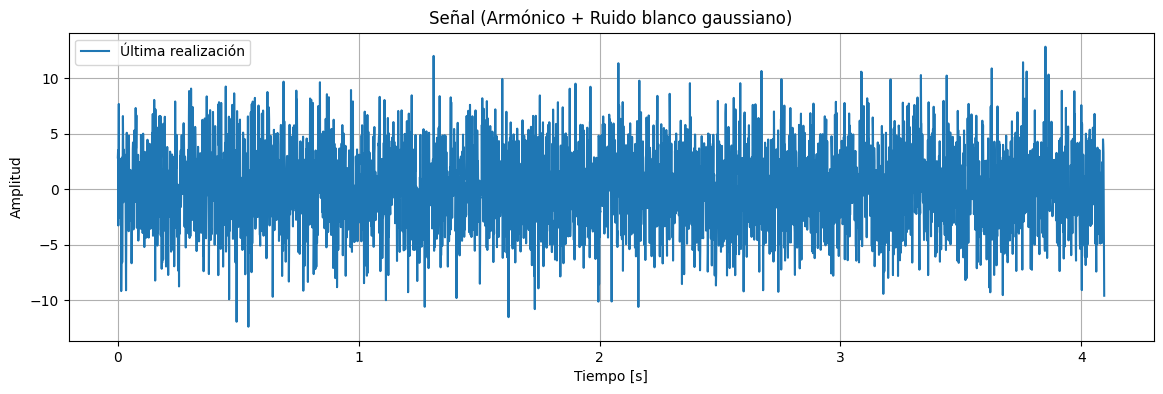

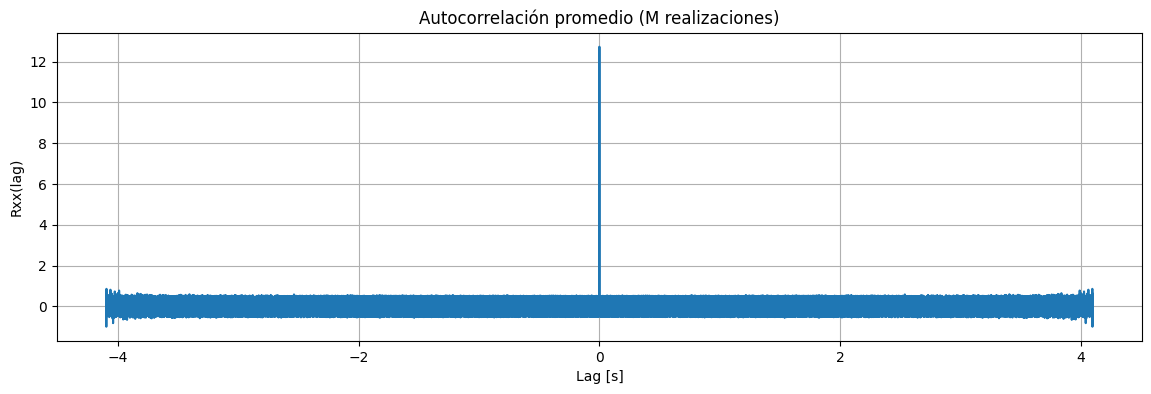

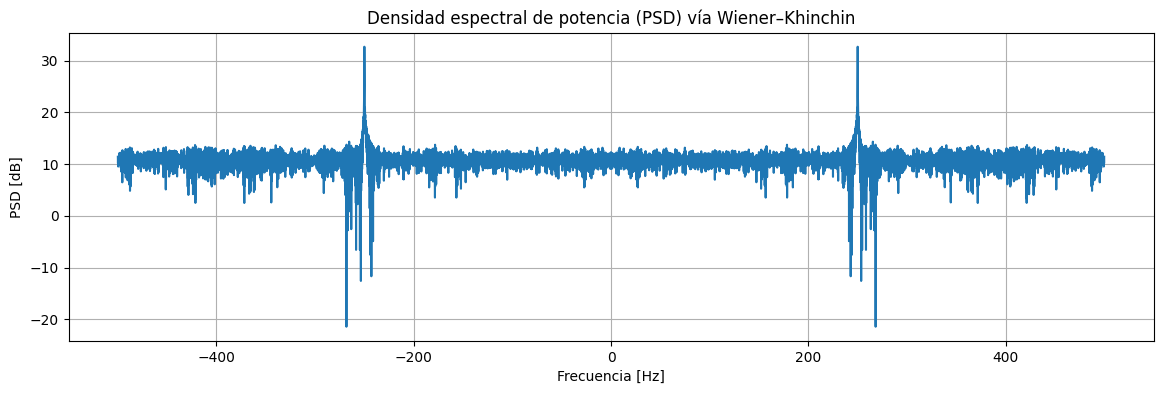

Average of 'a' estimates: 1.0038
Standard deviation of 'a' estimates: 0.0767


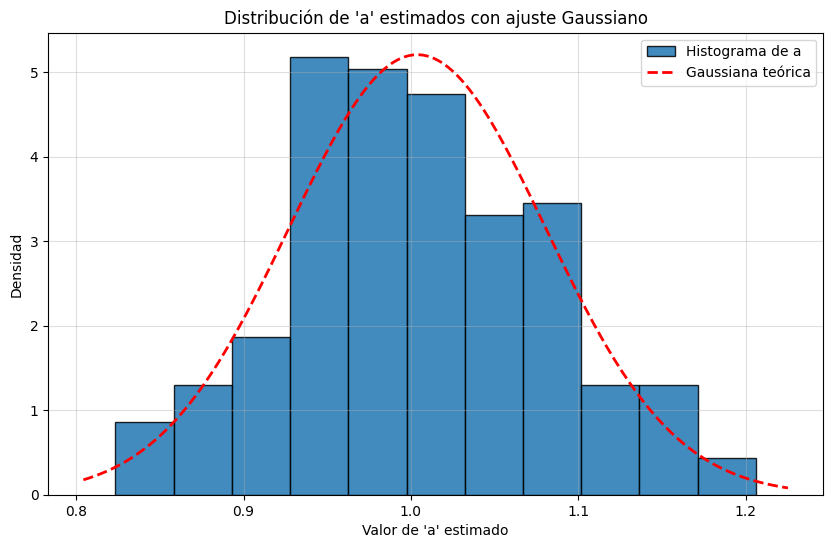

Estadística de Shapiro-Wilk: 0.9929
Valor p: 0.4499
No se puede rechazar H0: los datos podrían ser gaussianos.


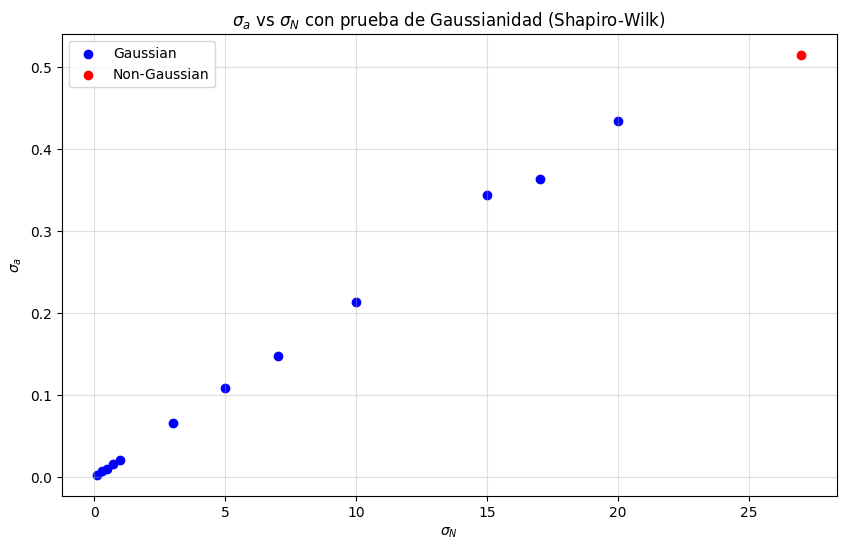

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, shapiro

# -----------------------------
# Parámetros de la simulación
# -----------------------------
fs = 1000          # Frecuencia de muestreo (Hz)
T = 4096           # Número de muestras por realización
M = 200            # Número de realizaciones
sigma = 3.5        # Desviación estándar del ruido (valor inicial)
A = 1.0            # Amplitud del armónico
f0 = 250           # Frecuencia del armónico (Hz)

# -----------------------------
# Inicializar acumuladores
# -----------------------------
R_sum = np.zeros(2*T-1)
a_estimates = []

# -----------------------------
# Bucle sobre realizaciones
# -----------------------------
for m in range(M):
    # Vector de tiempo
    t = np.arange(T) / fs

    # Ruido blanco gaussiano
    noise = np.random.normal(0, sigma, T)

    # Armónico
    s = A * np.cos(2 * np.pi * f0 * t)

    # Señal total
    x = s + noise

    # Estimate 'a' using FFT
    X = np.fft.fft(x)
    freqs_fft = np.fft.fftfreq(T, d=1/fs)
    f0_index = np.argmin(np.abs(freqs_fft - f0))
    a_hat = 2 * np.abs(X[f0_index]) / T
    a_estimates.append(a_hat)

    # Autocorrelación (modo "full")
    r = np.correlate(x, x, mode='full')
    lags_corr = np.arange(-T+1, T)
    r = r / (T - np.abs(lags_corr))
    R_sum += r

# -----------------------------
# Autocorrelación promedio
# -----------------------------
R_avg = R_sum / M
lags = np.arange(-T+1, T) / fs

# -----------------------------
# PSD via Wiener–Khinchin
# -----------------------------
Sx = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(R_avg)))
freqs = np.fft.fftshift(np.fft.fftfreq(len(R_avg), d=1/fs))
PSD = np.abs(Sx)

# -----------------------------
# Gráficas principales
# -----------------------------
plt.figure(figsize=(14,4))
plt.plot(t, x, label="Última realización")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal (Armónico + Ruido blanco gaussiano)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14,4))
plt.plot(lags, R_avg)
plt.xlabel("Lag [s]")
plt.ylabel("Rxx(lag)")
plt.title("Autocorrelación promedio (M realizaciones)")
plt.grid(True)
plt.show()

plt.figure(figsize=(14,4))
plt.plot(freqs, 10*np.log10(PSD + 1e-12))
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.title("Densidad espectral de potencia (PSD) vía Wiener–Khinchin")
plt.grid(True)
plt.show()

# -----------------------------
# Estadísticos de a
# -----------------------------
a_estimates = np.array(a_estimates)
mean_a = np.mean(a_estimates)
std_a = np.std(a_estimates)

print(f"Average of 'a' estimates: {mean_a:.4f}")
print(f"Standard deviation of 'a' estimates: {std_a:.4f}")

# -----------------------------
# Histograma + Gaussiana teórica
# -----------------------------
plt.figure(figsize=(10, 6))
plt.hist(a_estimates, bins='auto', density=True, alpha=0.85, edgecolor='k', label='Histograma de a')
xmin, xmax = plt.xlim()
x_pdf = np.linspace(xmin, xmax, 200)
p = norm.pdf(x_pdf, loc=mean_a, scale=std_a)
plt.plot(x_pdf, p, 'r--', linewidth=2, label='Gaussiana teórica')
plt.title("Distribución de 'a' estimados con ajuste Gaussiano")
plt.xlabel("Valor de 'a' estimado")
plt.ylabel("Densidad")
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

# -----------------------------
# Test de normalidad Shapiro-Wilk
# -----------------------------
statistic, p_value = shapiro(a_estimates)
print(f"Estadística de Shapiro-Wilk: {statistic:.4f}")
print(f"Valor p: {p_value:.4f}")
alpha = 0.05
if p_value > alpha:
    print("No se puede rechazar H0: los datos podrían ser gaussianos.")
else:
    print("Se rechaza H0: los datos probablemente no son gaussianos.")

# -----------------------------
# Barrido en distintos sigma
# -----------------------------
sigma_values = [0.1, 0.3, 0.5, 0.7, 1, 3, 5, 7, 10, 15, 17, 20, 27]
sigma_results = []
std_a_results = []
gaussianity_results = []

for current_sigma in sigma_values:
    R_sum = np.zeros(2*T-1)
    a_estimates = []
    for m in range(M):
        t = np.arange(T) / fs
        noise = np.random.normal(0, current_sigma, T)
        s = A * np.cos(2 * np.pi * f0 * t)
        x = s + noise
        X = np.fft.fft(x)
        freqs_fft = np.fft.fftfreq(T, d=1/fs)
        f0_index = np.argmin(np.abs(freqs_fft - f0))
        a_hat = 2 * np.abs(X[f0_index]) / T
        a_estimates.append(a_hat)
        r = np.correlate(x, x, mode='full')
        lags_corr = np.arange(-T+1, T)
        r = r / (T - np.abs(lags_corr))
        R_sum += r
    mean_a = np.mean(a_estimates)
    std_a = np.std(a_estimates)
    statistic, p_value = shapiro(a_estimates)
    is_gaussian = p_value > alpha
    sigma_results.append(current_sigma)
    std_a_results.append(std_a)
    gaussianity_results.append(is_gaussian)

# -----------------------------
# Plot: sigma_a vs sigma_N
# -----------------------------
gaussian_indices = [i for i, g in enumerate(gaussianity_results) if g]
non_gaussian_indices = [i for i, g in enumerate(gaussianity_results) if not g]

plt.figure(figsize=(10, 6))
plt.scatter([sigma_results[i] for i in gaussian_indices],
            [std_a_results[i] for i in gaussian_indices],
            color='blue', label='Gaussian')
plt.scatter([sigma_results[i] for i in non_gaussian_indices],
            [std_a_results[i] for i in non_gaussian_indices],
            color='red', label='Non-Gaussian')
plt.xlabel("$\sigma_N$")
plt.ylabel("$\sigma_a$")
plt.title("$\sigma_a$ vs $\sigma_N$ con prueba de Gaussianidad (Shapiro-Wilk)")
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

#Metodos de la PSD, Densidad Espectral de Potencia

### Métodos de estimación de PSD

**Periodograma clásico (`scipy.signal.periodogram`)**  
- Calcula la FFT de toda la señal de una sola vez.  
- **Ventaja:** fácil y directo.  
- **Desventaja:** mucha varianza (ruidoso), no se suaviza entre realizaciones.  



**Welch (versión manual sin `scipy`)**  
- Se divide la señal en segmentos.  
- Cada segmento se ventana (ej: ventana de Hann).  
- Se calcula la FFT de cada segmento.  
- Luego se promedian los espectros de todos los segmentos.  
- **Ventaja:** reduce varianza (espectro más suave).  
- **Desventaja:** pierde resolución en frecuencia.  



**Multitaper (`mne.time_frequency.psd_array_multitaper`)**  
- Se aplican varias ventanas ortogonales (tapers) a la señal.  
- Se calcula la FFT de cada versión “taperizada”.  
- Se promedian los espectros.  
- **Ventaja:** suaviza mucho y mantiene buena resolución.  
- **Nota:** es más robusto que Welch en señales cortas.  


In [ ]:
!pip install mne -q

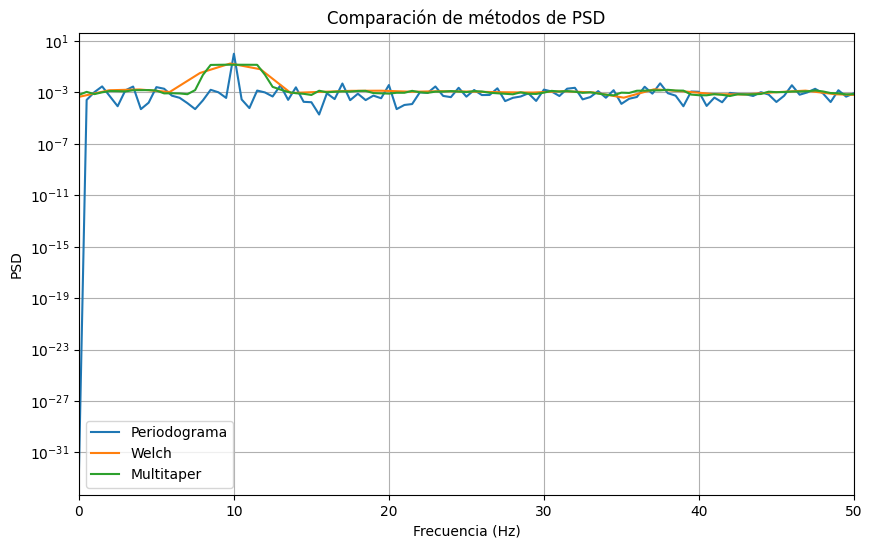

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, periodogram
from mne.time_frequency import psd_array_multitaper  # pip install mne

# Parámetros
fs = 500
T = 2
N = fs*T
t = np.arange(N)/fs

# Señal ejemplo: coseno 10 Hz + ruido
x = np.cos(2*np.pi*10*t) + 0.5*np.random.randn(N)

# Periodograma clásico
f_p, Pxx_p = periodogram(x, fs=fs)

# Welch
f_w, Pxx_w = welch(x, fs=fs, nperseg=256)

# Multitaper
Pxx_m, f_m = psd_array_multitaper(x, sfreq=fs, adaptive=True, normalization='full', verbose=0)

# Graficar
plt.figure(figsize=(10,6))
plt.semilogy(f_p, Pxx_p, label="Periodograma")
plt.semilogy(f_w, Pxx_w, label="Welch")
plt.semilogy(f_m, Pxx_m, label="Multitaper")
plt.xlim(0,50)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD")
plt.title("Comparación de métodos de PSD")
plt.legend()
plt.grid()
plt.show()

# Explicación del código

Este notebook realiza un **análisis estadístico y espectral** de una señal cosenoidal con ruido blanco gaussiano. A continuación se explica paso a paso qué hace cada parte y las ecuaciones relevantes.



## 1. Parámetros principales
Se fijan parámetros globales usados en la simulación:
- $f_s = 1000\ \text{Hz}$ (frecuencia de muestreo)  
- $T = 4096$ (número de muestras por realización)  
- $M = 200$ (número de realizaciones)  
- $A = 1.0$ (amplitud del coseno)  
- $f_0 = 250\ \text{Hz}$ (frecuencia del armónico)  
- $\alpha = 0.05$ (nivel de significancia para la prueba de normalidad)



## 2. Generación de la señal
La función `generar_senal(sigma, ...)` crea la señal discreta
$$
x[n] = A\cos(2\pi f_0 n / f_s) + n[n]
$$
donde $n[n]\sim \mathcal{N}(0,\sigma^2)$ es ruido blanco gaussiano con desviación estándar $\sigma$.


## 3. Estimación de la amplitud del armónico (FFT)
La función `estimar_a(x, fs, f0)` usa la FFT para obtener la componente en la frecuencia $f_0$.  
Si $X[k]$ es la FFT de $x[n]$ y $k_0$ es el índice de la frecuencia más cercana a $f_0$, la estimación de la amplitud es
$$
\hat a \;=\; \frac{2}{N}\,|X[k_0]|
$$
donde $N$ es la longitud de la señal. Este factor $2/N$ transforma la magnitud de la componente compleja en la amplitud del coseno.



## 4. Autocorrelación (modo "full")
La función `autocorrelacion(x)` calcula la autocorrelación normalizada en modo completo:
$$
R_x[\ell] \;=\; \frac{1}{N-|\ell|}\sum_{n} x[n]\,x[n+\ell],
$$
con $\ell$ siendo el desfase (lag). Esa normalización compensa el menor número de términos en los bordes.



## 5. Estimación de la PSD por Wiener–Khinchin
Si $R_x[\ell]$ es la autocorrelación promedio, la densidad espectral de potencia (PSD) se obtiene por transformada de Fourier:
$$
S_x(f) \;=\; \mathcal{F}\{R_x[\ell]\}.
$$
En el código se usa FFT sobre la autocorrelación promedio para obtener $S_x(f)$.


## 6. Método de Welch (implementado manualmente)
`welch_manual()` divide la señal en segmentos solapados, aplica una ventana $w[n]$ a cada segmento y promedia los periodogramas:
$$
P_{xx}(f)\;=\;\frac{1}{M}\sum_{i=1}^{M}\frac{1}{f_s N U}\big|\mathrm{FFT}(x_i\cdot w)\big|^2,
$$
donde $U=\frac{1}{N}\sum_{n} w[n]^2$ es el factor de normalización de la ventana y $M$ el número de segmentos usados. Este promedio reduce la varianza de la estimación.



## 7. Análisis estadístico de las estimaciones de $\hat a$
- Para un valor fijo de $\sigma$ se generan $M$ realizaciones, se calcula $\hat a$ en cada realización y se obtiene la **distribución empírica** de $\hat a$.  
- Se calculan la media $\overline{a}$ y la desviación típica $\sigma_a$.  
- Se aplica la prueba de **Shapiro–Wilk** (desde `scipy.stats.shapiro`) para comprobar si la distribución de $\{\hat a\}$ es compatible con una gaussiana. La hipótesis nula $H_0$ es “los datos provienen de una distribución normal”; rechazamos $H_0$ si $p \le \alpha$.



## 8. Barrido en $\sigma_N$ y gráfica final
Se barre sobre varios valores de ruido $\sigma_N$ (por ejemplo: $0.1,0.3,0.5,\dots$) y para cada uno se calcula:
- $\sigma_a$ (desviación de las estimaciones $\hat a$)  
- si la distribución pasa la prueba de Shapiro (booleano)

Se grafica $\sigma_a$ vs $\sigma_N$ diferenciando con color los casos donde la distribución **sí** se parece a una gaussiana y donde **no**.



## 9. Comparación de métodos PSD
Se construye una señal de prueba con varios armónicos y ruido y se comparan las estimaciones de PSD usando:
- **Periodograma** (scipy)  
- **Welch (manual)**  
- **Multitaper** (mne)

La comparación muestra la resolución y la varianza de cada método: el multitaper suele ser más estable (menor varianza), Welch reduce varianza promediando segmentos, y el periodograma es la estimación básica (más ruidosa).



#EXPLICACION TABLAS

1. **df (tabla principal de resultados por sigma y armónico)**  

Esta es la tabla más detallada. Cada fila corresponde a:  

- Un valor de sigma del ruido (`sigma_N`).  
- Un armónico (`harmonic_Hz`) (en tu caso 50 Hz y 120 Hz).  

Y las columnas muestran:  

- `mean_a`: media de las estimaciones de amplitud en las M realizaciones.  
- `std_a`: desviación estándar de esas estimaciones (qué tan dispersas fueron).  
- `shapiro_stat`: estadístico de la prueba Shapiro-Wilk.  
- `shapiro_pval`: p-valor de la prueba de normalidad.  
- `is_gaussian`: indicador booleano (`True` o `False`) según si pasó la prueba de normalidad al nivel de significancia α=0.05.  

Esta tabla es la **cruda**, con toda la información numérica de cada combinación de ruido y armónico.  

---

2. **pivot_std (σₐ vs σₙ por armónico)**  

Aquí se hace un pivote de la tabla original para que:  

- Las filas son los distintos valores de σ_N (ruido).  
- Las columnas son los armónicos (50 Hz, 120 Hz).  
- El valor en cada celda es la desviación estándar **σₐ** de las estimaciones de amplitud para ese caso.  

Esta tabla dice: **cómo crece la incertidumbre en la estimación de la amplitud cuando sube el nivel de ruido, separado por armónico**.  
Por ejemplo, si para σ_N=10 el armónico de 120 Hz tiene un σₐ mayor que el de 50 Hz, significa que ese armónico se ve más afectado por el ruido.  

---

3. **pivot_gauss (¿es gaussiana la distribución de amplitudes?)**  

Es un pivote similar, pero:  

- Filas = valores de σ_N (ruido).  
- Columnas = armónicos (50 Hz, 120 Hz).  
- Valores = `True` o `False` según la prueba de Shapiro-Wilk.  

Esta tabla muestra de un vistazo, para cada nivel de ruido y armónico, **si las estimaciones de amplitud se comportan como una variable gaussiana (`True`) o no (`False`)**.  

---
**En resumen:**  
- **Tabla 1 (`df`)** → datos completos (media, varianza, normalidad).  
- **Tabla 2 (`pivot_std`)** → cómo crece la dispersión de las estimaciones al aumentar el ruido (σₐ vs σ_N).  
- **Tabla 3 (`pivot_gauss`)** → qué tan bien se ajustan esas estimaciones a una distribución normal.  



Tabla resumen (primeras filas):


,sigma_N,harmonic_Hz,mean_a,std_a,shapiro_stat,shapiro_pval,is_gaussian
0,0.1,50,0.935579,0.002343,0.990603,0.218479,True
1,0.1,120,0.398026,0.001991,0.993690,0.555344,True
2,0.3,50,0.935624,0.006319,0.992530,0.401628,True
3,0.3,120,0.397680,0.006598,0.987941,0.088309,True
4,0.5,50,0.935617,0.010069,0.995898,0.870720,True
5,0.5,120,0.398152,0.010384,0.994749,0.712875,True
6,0.7,50,0.934580,0.014777,0.989378,0.144760,True
7,0.7,120,0.397734,0.015281,0.995614,0.835443,True
8,1.0,50,0.937518,0.020330,0.985205,0.034253,False
9,1.0,120,0.397432,0.021402,0.995540,0.825659,True


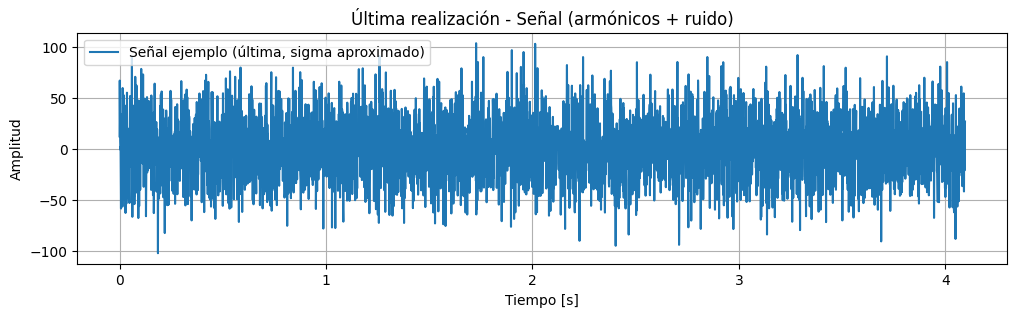

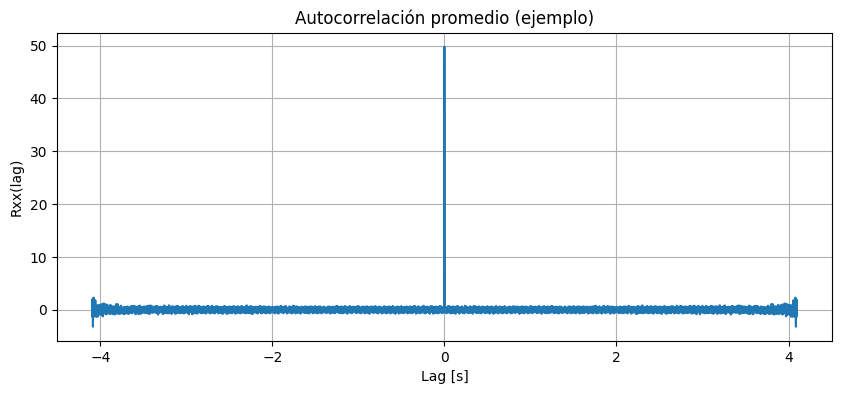

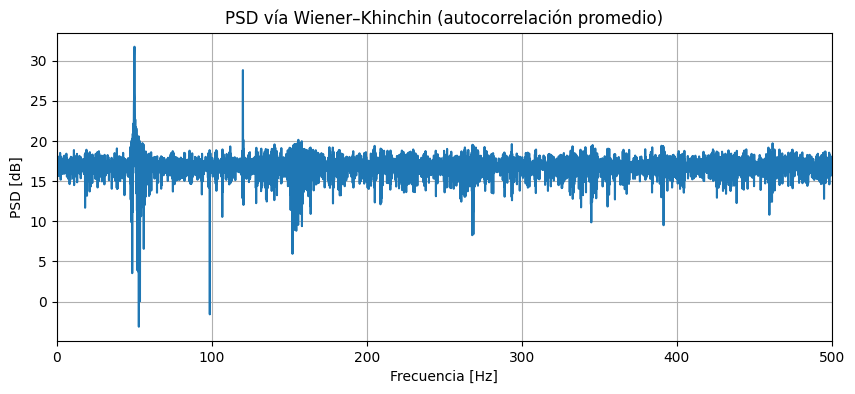

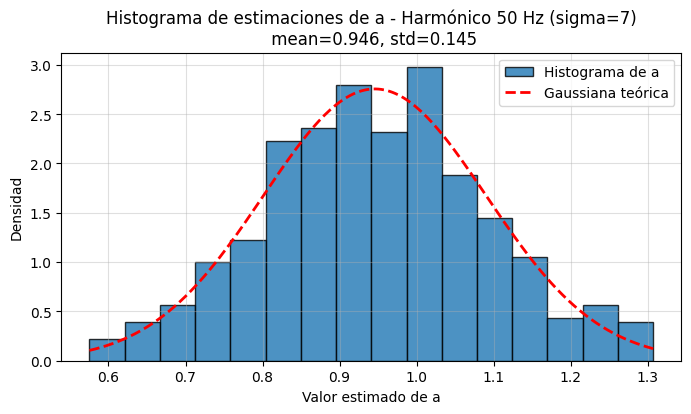

Harmónico 50 Hz - Shapiro stat=0.9959, p=0.2145 -> Gaussian


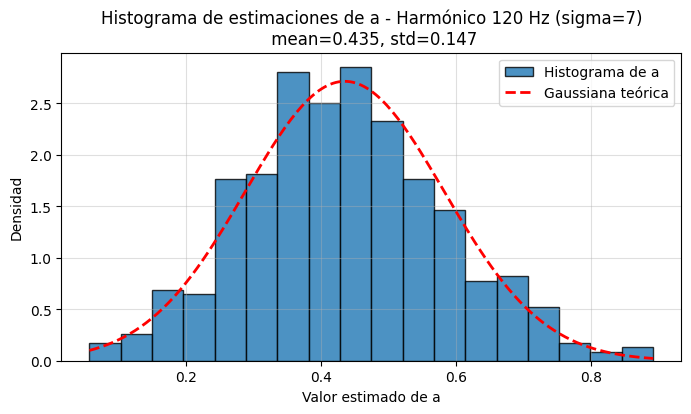

Harmónico 120 Hz - Shapiro stat=0.9953, p=0.1313 -> Gaussian


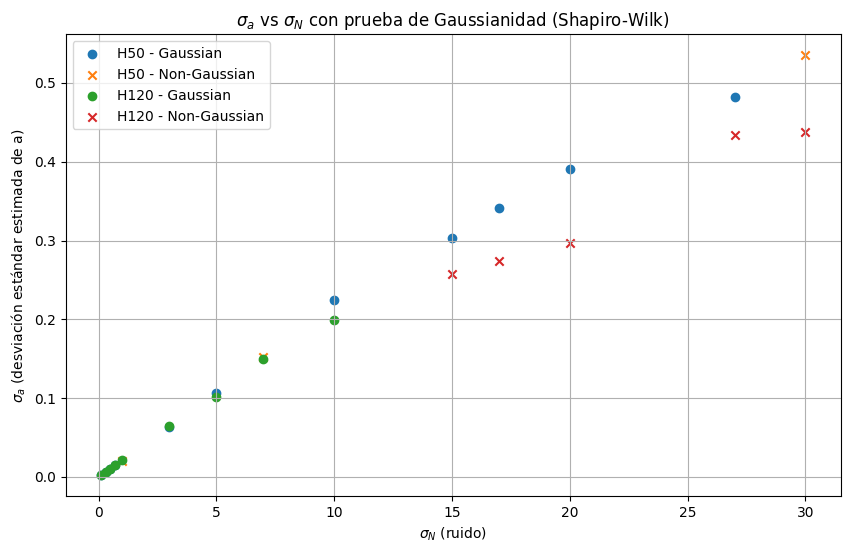

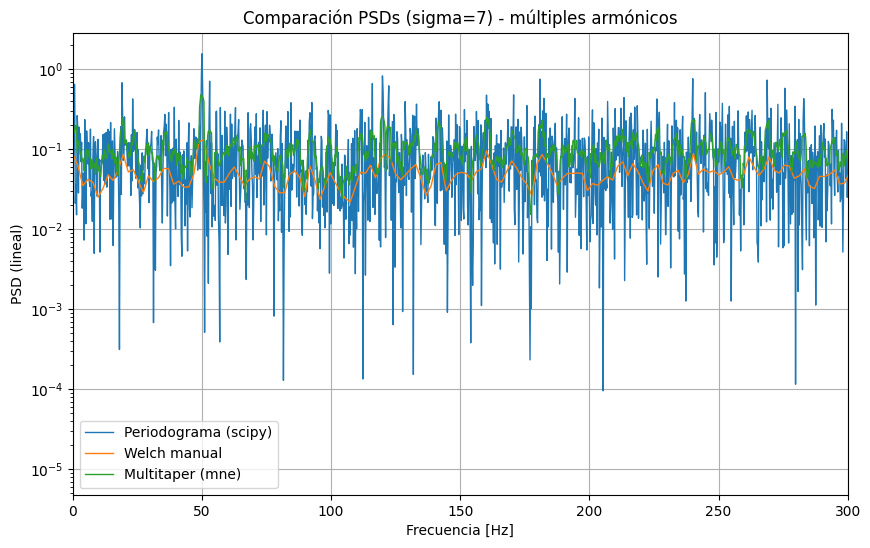


Resumen listo para informe (muestras):

Desviación estándar de 'a' por sigma y harmonic (pivot):


harmonic_Hz,50,120
sigma_N,,
0.1,0.002343,0.001991
0.3,0.006319,0.006598
0.5,0.010069,0.010384
0.7,0.014777,0.015281
1.0,0.020330,0.021402
3.0,0.063430,0.064027
5.0,0.105974,0.101138
7.0,0.151544,0.150097
10.0,0.224392,0.199431



Gaussianidad (True=parece Gaussiana) por sigma y harmonic (pivot):


harmonic_Hz,50,120
sigma_N,,
0.1,True,True
0.3,True,True
0.5,True,True
0.7,True,True
1.0,False,True
3.0,True,True
5.0,True,True
7.0,False,True
10.0,True,True



CSV 'resumen_estimates_sigma_vs_harmonics.csv'


In [ ]:
# Taller 24 septiembre - Joel Hamerson
# Código corregido y robusto en un solo bloque.
# Requisitos: numpy, matplotlib, scipy, mne, scipy.stats, pandas
# Si falta mne: !pip install mne

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, shapiro
from scipy.signal import periodogram  # Solo para periodograma clásico
from mne.time_frequency import psd_array_multitaper
import pandas as pd
from IPython.display import display  # útil en Jupyter

# -----------------------------
# Funciones auxiliares
# -----------------------------

def generate_signal(fs, T_samples, harmonics, amplitudes, noise_sigma):
    """
    Genera una señal sumando varios armónicos (cosenos) y ruido blanco gaussiano.
    harmonics: lista de frecuencias en Hz
    amplitudes: lista de amplitudes (mismo tamaño que harmonics)
    """
    t = np.arange(T_samples) / fs
    s = np.zeros_like(t)
    for f, A in zip(harmonics, amplitudes):
        s += A * np.cos(2*np.pi*f*t)
    noise = np.random.normal(0, noise_sigma, size=T_samples)
    x = s + noise
    return t, x, s

def estimate_amplitudes_fft(x, fs, harmonics):
    """
    Estima la amplitud de cada armónico usando la FFT (ventana rectangular)
    Regresa vector de amplitudes estimadas (una por frecuencia pedida).
    Usa factor 2/T para convertir componente de fft a amplitud de coseno.
    """
    N = len(x)
    X = np.fft.fft(x)
    freqs = np.fft.fftfreq(N, d=1/fs)
    amps = []
    for f0 in harmonics:
        idx = np.argmin(np.abs(freqs - f0))
        a_hat = 2 * np.abs(X[idx]) / N
        amps.append(a_hat)
    return np.array(amps)

def autocorr_full_normalized(x):
    """
    Autocorrelación modo 'full' y normalizada por (N-|lag|)
    """
    N = len(x)
    r = np.correlate(x, x, mode='full')
    lags = np.arange(-N+1, N)
    r = r / (N - np.abs(lags))
    return r

def psd_from_autocorr_wiener_khinchin(R_avg, fs):
    """
    PSD a partir de autocorrelación promedio (Wiener-Khinchin).
    Devuelve freqs y PSD (lineal, no en dB).
    """
    Sx = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(R_avg)))
    freqs = np.fft.fftshift(np.fft.fftfreq(len(R_avg), d=1/fs))
    PSD = np.abs(Sx)
    return freqs, PSD

def periodogram_scipy(x, fs):
    """
    Periodograma clásico usando scipy.signal.periodogram
    """
    f, Pxx = periodogram(x, fs=fs, scaling='density', window='boxcar', detrend=False)
    return f, Pxx

def welch_manual(x, fs, nperseg=256, noverlap=None, window='hann'):
    """
    Implementación manual de Welch sin usar scipy.
    - Ajusta nperseg si la señal es más corta.
    - Asegura noverlap < nperseg.
    - Devuelve (freqs, Pxx) para rfft (frecuencias positivas).
    """
    N = len(x)
    # ajustar nperseg si es mayor que N
    nperseg = int(min(nperseg, N)) if nperseg > 0 else N
    if nperseg <= 0:
        raise ValueError("nperseg debe ser > 0")

    if noverlap is None:
        noverlap = nperseg // 2
    # asegurar noverlap < nperseg
    if noverlap >= nperseg:
        noverlap = max(0, nperseg - 1)

    step = nperseg - noverlap
    if step <= 0:
        # como seguro noverlap < nperseg esto no debería ocurrir, pero por seguridad lo ajustamos
        step = 1

    # seleccionar ventana
    if window == 'hann':
        win = np.hanning(nperseg)
    elif window == 'rect':
        win = np.ones(nperseg)
    else:
        raise ValueError("window no soportada")

    U = np.sum(win**2)  # factor de normalización de la energía
    # calcular segmentos
    segments = []
    starts = np.arange(0, N - nperseg + 1, step)
    for start in starts:
        seg = x[start:start+nperseg] * win
        segments.append(seg)
    if len(segments) == 0:
        # si la señal es más corta que nperseg -> usar una sola ventana con padding
        seg = np.zeros(nperseg)
        seg[:N] = x
        seg = seg * win
        segments = [seg]

    # calcular periodogramas de cada segmento y promediar
    S_accum = None
    for seg in segments:
        X = np.fft.rfft(seg, n=nperseg)
        Pxx_seg = (np.abs(X)**2) / (fs * U)
        if S_accum is None:
            S_accum = Pxx_seg
        else:
            S_accum += Pxx_seg
    Pxx = S_accum / len(segments)
    freqs = np.fft.rfftfreq(nperseg, d=1/fs)
    return freqs, Pxx

def multitaper_mne(x, fs, adaptive=True, normalization='full'):
    """
    PSD multitaper usando mne.time_frequency.psd_array_multitaper
    Devuelve (freqs, Pxx)
    """
    # psd_array_multitaper returns (psd, freqs)
    Pxx, freqs = psd_array_multitaper(x, sfreq=fs, adaptive=adaptive, normalization=normalization, verbose=0)
    return freqs, Pxx

# -----------------------------
# Main: simulación, análisis y gráficos
# -----------------------------

def main():
    # Parámetros generales
    fs = 1000            # frecuencia de muestreo (Hz)
    T = 4096             # número de muestras por realización (T muestras)
    M = 200              # número de realizaciones
    # Usamos varios armónicos (caso solicitado)
    harmonics = [50, 120]      # Hz (más de uno para comparación de PSDs)
    amplitudes = [1.0, 0.6]    # amplitudes de cada armónico
    # Valores de sigma del ruido a barrer (incluye los que pediste y algunos extra)
    sigma_values = [0.1, 0.3, 0.5, 0.7, 1, 3, 5, 7, 10, 15, 17, 20, 27, 30]
    alpha = 0.05  # nivel para Shapiro-Wilk

    # Si quieres un sigma ejemplo fijo, ponlo aquí; si no está en la lista, se ajustará
    example_sigma = 3.5
    if example_sigma not in sigma_values:
        # usa median de la lista para visualizaciones si el elegido no está
        example_sigma = sigma_values[len(sigma_values)//2]

    # Acumuladores para reporte
    report_rows = []
    std_a_results_per_harmonic = {h: [] for h in harmonics}
    gaussianity_per_harmonic = {h: [] for h in harmonics}

    # Para una sigma ejemplo (visualizaciones), guardamos la última señal
    last_x_example = None
    last_t_example = None
    last_mean_R = None
    last_R_avg = None  # fallback del último sigma procesado

    # Barrido por sigma del ruido
    for sigma in sigma_values:
        # acumuladores por sigma
        R_sum = np.zeros(2*T - 1)
        amps_all_realizations = []  # shape (M, n_harmonics)

        for m in range(M):
            t, x, s = generate_signal(fs, T, harmonics, amplitudes, noise_sigma=sigma)
            last_x_example = x
            last_t_example = t
            # estimar amplitudes via FFT
            amps = estimate_amplitudes_fft(x, fs, harmonics)
            amps_all_realizations.append(amps)
            # autocorrelation
            r = autocorr_full_normalized(x)
            R_sum += r

        amps_all_realizations = np.array(amps_all_realizations)  # shape (M, n_harmonics)
        R_avg = R_sum / M
        last_R_avg = R_avg.copy()  # guardamos siempre el último R_avg por si necesitamos fallback

        if sigma == example_sigma:
            last_mean_R = R_avg.copy()

        # para cada armónico, testear normalidad y guardar std, media, pvalue
        for ih, h in enumerate(harmonics):
            arr = amps_all_realizations[:, ih]
            mean_a = np.mean(arr)
            std_a = np.std(arr, ddof=0)
            # Si M es pequeño o arr tiene valores extremos, shapiro puede fallar; envolver en try:
            try:
                stat, pval = shapiro(arr)
            except Exception as e:
                stat, pval = np.nan, np.nan
            is_gauss = False if np.isnan(pval) else (pval > alpha)
            report_rows.append({
                'sigma_N': sigma,
                'harmonic_Hz': h,
                'mean_a': mean_a,
                'std_a': std_a,
                'shapiro_stat': stat,
                'shapiro_pval': pval,
                'is_gaussian': is_gauss
            })
            std_a_results_per_harmonic[h].append(std_a)
            gaussianity_per_harmonic[h].append(is_gauss)

    # Si last_mean_R no fue asignado (ej. example_sigma no estuvo), usar último R_avg calculado
    if last_mean_R is None:
        if last_R_avg is not None:
            last_mean_R = last_R_avg.copy()
        else:
            # como último recurso, generar una señal y calcular su autocorrelación
            _, x_tmp, _ = generate_signal(fs, T, harmonics, amplitudes, noise_sigma=sigma_values[0])
            last_mean_R = autocorr_full_normalized(x_tmp)

    # -----------------------------
    # Mostrar resumen en tabla (pandas)
    # -----------------------------
    df = pd.DataFrame(report_rows)
    pivot_std = df.pivot(index='sigma_N', columns='harmonic_Hz', values='std_a')
    pivot_gauss = df.pivot(index='sigma_N', columns='harmonic_Hz', values='is_gaussian')
    print("\nTabla resumen (primeras filas):")
    display(df.head(16))

    # Guardar CSV para informe si quieres
    df.to_csv("resumen_estimates_sigma_vs_harmonics.csv", index=False)

    # -----------------------------
    # Gráficas solicitadas
    # -----------------------------

    # 1) Señal ejemplo (última realización disponible)
    if (last_t_example is not None) and (last_x_example is not None):
        plt.figure(figsize=(12,3))
        plt.plot(last_t_example, last_x_example, label=f"Señal ejemplo (última, sigma aproximado)")
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Amplitud")
        plt.title("Última realización - Señal (armónicos + ruido)")
        plt.grid(True)
        plt.legend()
        plt.show()

    # 2) Autocorrelación promedio ejemplo y PSD por Wiener-Khinchin
    lags = np.arange(-T+1, T) / fs
    if last_mean_R is not None:
        plt.figure(figsize=(10,4))
        plt.plot(lags, last_mean_R)
        plt.xlabel("Lag [s]")
        plt.ylabel("Rxx(lag)")
        plt.title(f"Autocorrelación promedio (ejemplo)")
        plt.grid(True)
        plt.show()

        freqs_wk, PSD_wk = psd_from_autocorr_wiener_khinchin(last_mean_R, fs)
        # asegurar que freqs_wk y PSD_wk no sean None
        if freqs_wk is not None and PSD_wk is not None:
            plt.figure(figsize=(10,4))
            idx = np.argsort(freqs_wk)
            plt.plot(freqs_wk[idx], 10*np.log10(PSD_wk[idx] + 1e-12))
            plt.xlim(0, fs/2)
            plt.xlabel("Frecuencia [Hz]")
            plt.ylabel("PSD [dB]")
            plt.title("PSD vía Wiener–Khinchin (autocorrelación promedio)")
            plt.grid(True)
            plt.show()

    # 3) Histograma de estimaciones de 'a' para cada harmonic en un sigma de ejemplo y ajuste gaussiano
    sigma_for_hist = example_sigma
    M_hist = 500
    sigma = sigma_for_hist
    amps_hist = {h: [] for h in harmonics}
    for m in range(M_hist):
        _, x, _ = generate_signal(fs, T, harmonics, amplitudes, noise_sigma=sigma)
        amps = estimate_amplitudes_fft(x, fs, harmonics)
        for ih, h in enumerate(harmonics):
            amps_hist[h].append(amps[ih])
    for h in harmonics:
        arr = np.array(amps_hist[h])
        mean_a = arr.mean()
        std_a = arr.std()
        plt.figure(figsize=(8,4))
        plt.hist(arr, bins='auto', density=True, alpha=0.8, edgecolor='k', label='Histograma de a')
        x_pdf = np.linspace(arr.min(), arr.max(), 200)
        p = norm.pdf(x_pdf, loc=mean_a, scale=std_a)
        plt.plot(x_pdf, p, 'r--', linewidth=2, label='Gaussiana teórica')
        plt.title(f"Histograma de estimaciones de a - Harmónico {h} Hz (sigma={sigma_for_hist})\n mean={mean_a:.3f}, std={std_a:.3f}")
        plt.xlabel("Valor estimado de a")
        plt.ylabel("Densidad")
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.show()
        # Shapiro
        try:
            stat, pval = shapiro(arr)
        except Exception:
            stat, pval = np.nan, np.nan
        print(f"Harmónico {h} Hz - Shapiro stat={stat:.4f}, p={pval:.4f} -> {'Gaussian' if (not np.isnan(pval) and pval>alpha) else 'Non-gaussian'}")

    # 4) sigma_a vs sigma_N con marcadores diferenciados por Gaussian/Non-Gaussian para cada harmonic
    plt.figure(figsize=(10,6))
    for h in harmonics:
        sigmas = sigma_values
        stds = std_a_results_per_harmonic[h]
        gauss_flags = gaussianity_per_harmonic[h]
        # proteger por longitud
        if len(stds) != len(sigmas):
            # recortar o pad con NaN según convenga
            minlen = min(len(stds), len(sigmas))
            sigmas_plot = sigmas[:minlen]
            stds_plot = stds[:minlen]
            flags_plot = gauss_flags[:minlen]
        else:
            sigmas_plot = sigmas
            stds_plot = stds
            flags_plot = gauss_flags
        sig_gauss = [s for s, g in zip(sigmas_plot, flags_plot) if g]
        std_gauss = [st for st, g in zip(stds_plot, flags_plot) if g]
        sig_nongauss = [s for s, g in zip(sigmas_plot, flags_plot) if not g]
        std_nongauss = [st for st, g in zip(stds_plot, flags_plot) if not g]
        plt.scatter(sig_gauss, std_gauss, label=f'H{h} - Gaussian', marker='o')
        plt.scatter(sig_nongauss, std_nongauss, label=f'H{h} - Non-Gaussian', marker='x')
    plt.xlabel(r'$\sigma_N$ (ruido)')
    plt.ylabel(r'$\sigma_a$ (desviación estándar estimada de a)')
    plt.title(r'$\sigma_a$ vs $\sigma_N$ con prueba de Gaussianidad (Shapiro-Wilk)')
    plt.grid(True)
    plt.legend()
    plt.show()

    # 5) Comparación de PSDs (Periodograma, Welch manual y Multitaper) para una señal ejemplo con más de un armónico
    sigma_plot = example_sigma
    t, x_plot, s_plot = generate_signal(fs, T, harmonics, amplitudes, noise_sigma=sigma_plot)
    f_p, Pxx_p = periodogram_scipy(x_plot, fs)
    # Ajustar nperseg para welch_manual por si T es menor
    nperseg = 512
    if nperseg > len(x_plot):
        nperseg = len(x_plot)
    f_w, Pxx_w = welch_manual(x_plot, fs, nperseg=nperseg, noverlap=nperseg//2, window='hann')
    f_m, Pxx_m = multitaper_mne(x_plot, fs)

    plt.figure(figsize=(10,6))
    # proteger antes de graficar si alguna salida tuviera problemas
    if (f_p is not None) and (Pxx_p is not None):
        plt.semilogy(f_p, Pxx_p, label='Periodograma (scipy)', linewidth=1)
    if (f_w is not None) and (Pxx_w is not None):
        plt.semilogy(f_w, Pxx_w, label='Welch manual', linewidth=1)
    if (f_m is not None) and (Pxx_m is not None):
        # psd_array_multitaper puede devolver Pxx de distinto tamaño; si es 2D, promediar en el eje 0
        if Pxx_m.ndim == 2:
            Pxx_m_plot = Pxx_m.mean(axis=0)
        else:
            Pxx_m_plot = Pxx_m
        plt.semilogy(f_m, Pxx_m_plot, label='Multitaper (mne)', linewidth=1)
    plt.xlim(0, 300)
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("PSD (lineal)")
    plt.title(f"Comparación PSDs (sigma={sigma_plot}) - múltiples armónicos")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 6) Mostrar algunos valores resumidos listos para pegar en informe
    print("\nResumen listo para informe (muestras):")
    print("\nDesviación estándar de 'a' por sigma y harmonic (pivot):")
    display(pivot_std)
    print("\nGaussianidad (True=parece Gaussiana) por sigma y harmonic (pivot):")
    display(pivot_gauss)

    # Guardar CSV para informe
    df.to_csv("resumen_estimates_sigma_vs_harmonics.csv", index=False)
    print("\nCSV 'resumen_estimates_sigma_vs_harmonics.csv'")


if __name__ == "__main__":
    main()
